In [59]:
# import the libraries
import pandas as pd
from fbprophet import Prophet
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [60]:
# load data
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header=0)
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [61]:
# prepare expected column names
# Prophet takes as input a dataframe with columns called 'ds' and 'y' (plus an index)
df.columns = ['ds', 'y']
df['ds']= pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


In [62]:
# get a train set (by dropping last rows)
train_df = df.drop(df.index[-12:])
train_df.tail()

,ds,y
91,1967-08-01,13434
92,1967-09-01,13598
93,1967-10-01,17187
94,1967-11-01,16119
95,1967-12-01,13713


In [63]:
# get a test set (by taking last rows of the original df)
test_df = df.iloc[-12:,:]
test_df.head()

,ds,y
96,1968-01-01,13210
97,1968-02-01,14251
98,1968-03-01,20139
99,1968-04-01,21725
100,1968-05-01,26099


In [64]:
# get y_true values from the test set (used to compute mae)
y_true = test_df['y'].values

In [65]:
# instantiate the model
model = Prophet()
# fit the model
model.fit(train_df)

INFO:fbprophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [66]:
# get the 'ds' values to use to predict
X_test = pd.DataFrame(test_df['ds'])
X_test

,ds
96,1968-01-01
97,1968-02-01
98,1968-03-01
99,1968-04-01
100,1968-05-01
101,1968-06-01
102,1968-07-01
103,1968-08-01
104,1968-09-01
105,1968-10-01


In [67]:
# predict test values
y_pred = model.predict(X_test) # outputs a dataframe, the predicted value is in col yhat
y_hat = y_pred['yhat'].values

In [68]:
# see how the results are presented
y_pred.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1968-01-01,17591.486094,12925.254021,16163.745381,17591.341966,17591.644305,-3078.492853,-3078.492853,-3078.492853,-3078.492853,-3078.492853,-3078.492853,0.0,0.0,0.0,14512.993241
1,1968-02-01,17639.342540,13427.813604,16489.694883,17637.918909,17641.136424,-2708.433957,-2708.433957,-2708.433957,-2708.433957,-2708.433957,-2708.433957,0.0,0.0,0.0,14930.908583
2,1968-03-01,17684.111474,19280.566245,22385.597295,17680.772876,17688.430013,3158.053867,3158.053867,3158.053867,3158.053867,3158.053867,3158.053867,0.0,0.0,0.0,20842.165341
3,1968-04-01,17731.967920,21528.530886,24613.993409,17725.430508,17739.157817,5268.688682,5268.688682,5268.688682,5268.688682,5268.688682,5268.688682,0.0,0.0,0.0,23000.656602
4,1968-05-01,17778.280610,21856.146875,24913.008806,17768.046284,17788.649497,5571.867867,5571.867867,5571.867867,5571.867867,5571.867867,5571.867867,0.0,0.0,0.0,23350.148477


In [69]:
# compute the mae
mae = mean_absolute_error(y_true, y_hat)
print('mae:', mae)

mae: 1336.813762330031


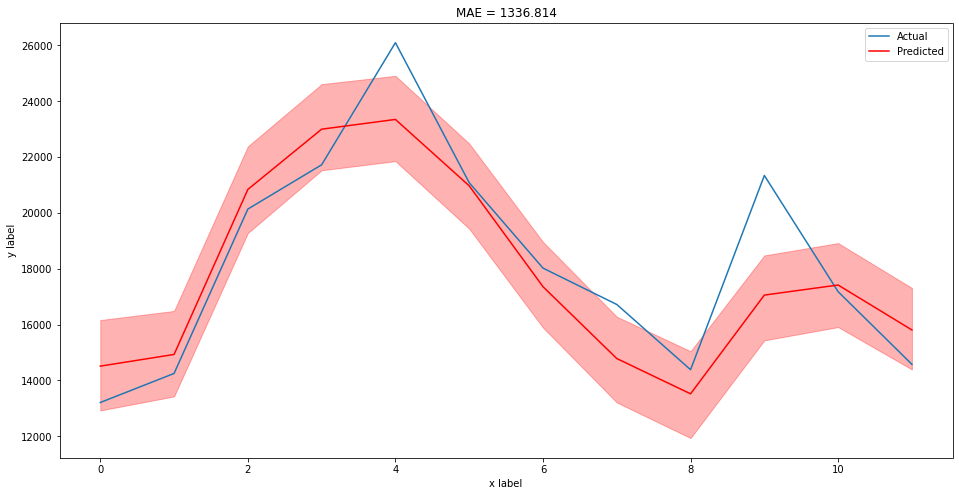

In [70]:
# plot expected vs actual
plt.figure(figsize=(16,8))
plt.plot(y_true, label='Actual')
plt.plot(y_hat, label='Predicted', color='r')
plt.legend()
plt.xlabel('x label')
plt.ylabel('y label')
plt.title('MAE = {}'.format(round(mae,3)))
plt.fill_between(range(len(y_true)), y_pred['yhat_lower'].values, y_pred['yhat_upper'].values, alpha=0.3, color='r')

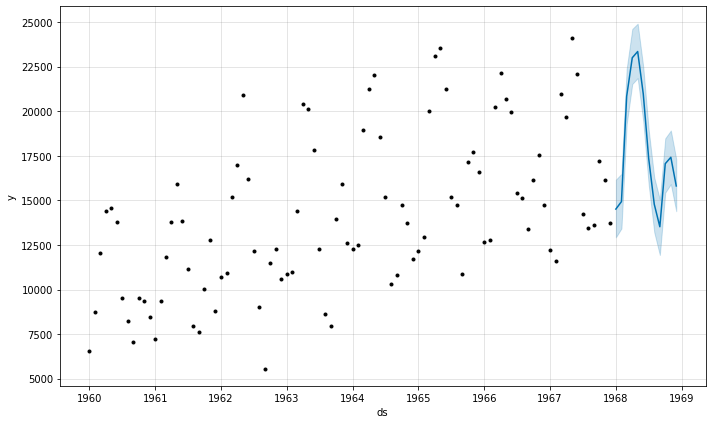

In [72]:
# plot the model
model.plot(y_pred) # it plots the trainig data and the prediction with the error margin
plt.show()

# SAME TEST BUT WITH MACHINE LEARNING

In [73]:
# load data
path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header=0)
df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [75]:
# check dataframe's info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   108 non-null    object
 1   Sales   108 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ KB


In [76]:
# get statistical description of the data
df.describe().T.style.background_gradient(subset=["std"], cmap="Reds").background_gradient(subset=["mean"], cmap="Reds")

,count,mean,std,min,25%,50%,75%,max
Sales,108.000000,14595.111111,4525.213913,5568.000000,11391.250000,14076.000000,17595.750000,26099.000000


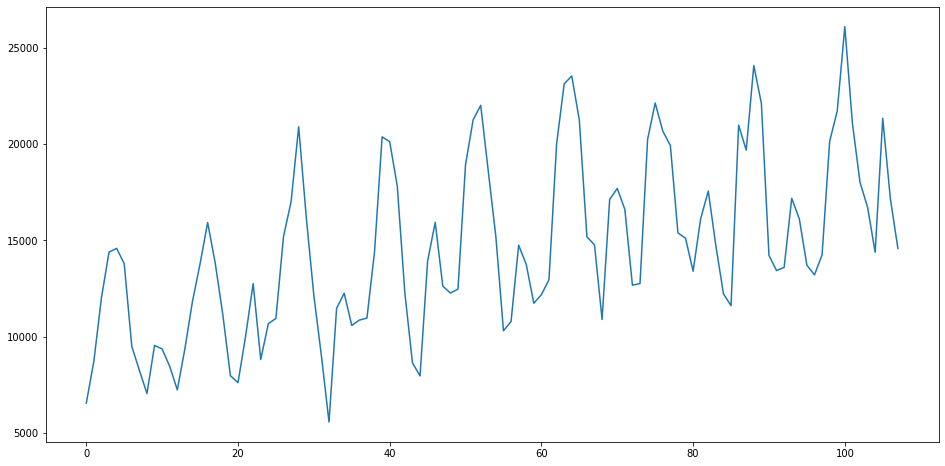

In [79]:
# plot time series data
plt.figure(figsize=(16,8))
#plt.plot(df['datetime'].iloc[-500:], df['count'].iloc[-500:])
df['Sales'].plot()

Text(0.5, 1.0, 'Noise')

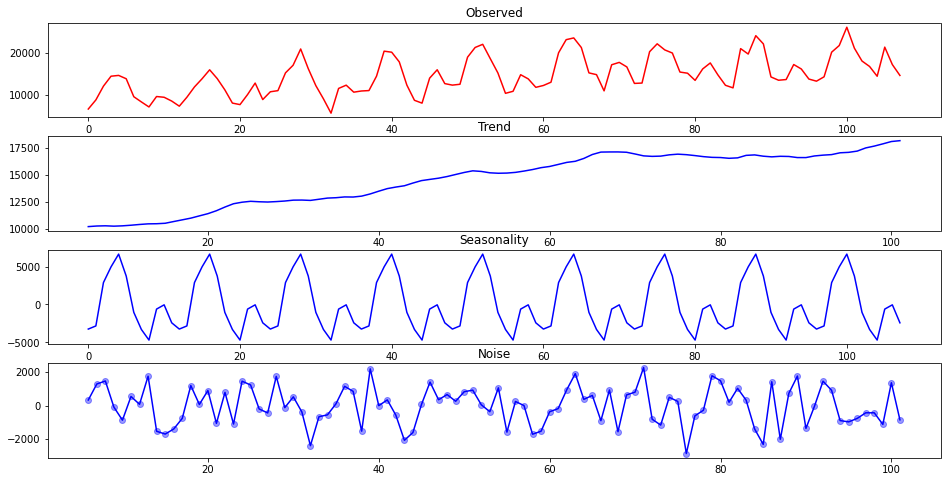

In [90]:
# seasonal decompose
from statsmodels.tsa.seasonal import seasonal_decompose

dec_results = seasonal_decompose(df['Sales'], freq=12)
obs = dec_results.observed
seas = dec_results.seasonal
trend = dec_results.trend
noise = dec_results.resid

# plot the decomposition (along with observed data)
fig, axs = plt.subplots(4, figsize=(16,8))
    
axs[0].plot(obs, color='r')
axs[0].set_title('Observed')
    
axs[1].plot(trend, color='b')
axs[1].set_title('Trend')
    
axs[2].plot(seas, color='b')
axs[2].set_title('Seasonality')
    
axs[3].plot(noise, color='b')
axs[3].scatter(y=noise, x=range(len(noise)), color='b', alpha=0.4)
axs[3].set_title('Noise') 

<function matplotlib.pyplot.show>

<Figure size 1152x576 with 0 Axes>

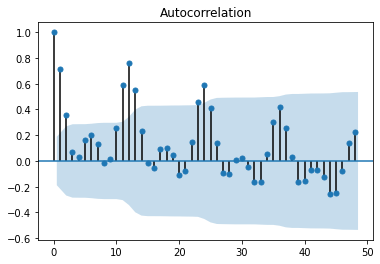

In [91]:
from statsmodels.graphics.tsaplots import plot_acf
# check for autocorrelation
plt.figure(figsize=(16,8))
# plot autocorrelation plot with up to 48 lags (2 days)
plot_acf(df['Sales'],lags=48)
plt.show

In [100]:
df.head()

,Sales,month,year
Month,,,
1960-01-01,6550,1,1960
1960-02-01,8728,2,1960
1960-03-01,12026,3,1960
1960-04-01,14395,4,1960
1960-05-01,14587,5,1960


In [93]:
df.set_index(pd.to_datetime(df['Month']), inplace=True)

In [95]:
df.drop('Month', axis=1, inplace=True)

In [99]:
df['month'] = df.index.month
df['year'] = df.index.year

In [101]:
X = df[['month', 'year']]
y = df['Sales']

In [104]:
X_train, X_test = X.iloc[:-12,:], X.iloc[-12:,:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]

In [105]:
from sklearn.ensemble import RandomForestRegressor
clf = RandomForestRegressor()
clf.fit(X_train, y_train)

RandomForestRegressor()

In [106]:
y_hat = clf.predict(X_test)

In [107]:
mae = mean_absolute_error(y_test, y_hat)
mae

1812.8974999999998

In [115]:
# add lag
df_lag = df.copy()
df_lag['one_year_behind'] = df['Sales'].shift(12)
df_lag.dropna(axis=0, how='any', inplace=True)

In [117]:
X = df_lag.drop('Sales', axis=1)
y = df_lag['Sales']
X_train, X_test = X.iloc[:-12,:], X.iloc[-12:,:]
y_train, y_test = y.iloc[:-12], y.iloc[-12:]

In [121]:
clf = RandomForestRegressor()
clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)

In [122]:
mae = mean_absolute_error(y_test, y_hat)
mae

1898.86

In [123]:
from lightgbm import LGBMRegressor
clf = LGBMRegressor(random_state=42)
clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
mae

1644.4700032498076

# With time series split cross validation

In [136]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
tscv = TimeSeriesSplit(n_splits=3)
model = LGBMRegressor(random_state=42)
parameters = {'n_estimators':range(50,750,100), 'boosting_type':['gbdt', 'dart'] 'max_depth':range(2,16,2)}



grid_search = GridSearchCV(model, parameters, cv=tscv.split(X_train), 
                               scoring='neg_mean_absolute_error', return_train_score=True, 
                               verbose=6, n_jobs=-1)

In [137]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 49 candidates, totalling 147 fits


GridSearchCV(cv=<generator object TimeSeriesSplit.split at 0x7fb1551107d0>,
             estimator=LGBMRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(2, 16, 2),
                         'n_estimators': range(50, 750, 100)},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=6)

In [138]:
y_hat = grid_search.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
mae

1526.651638582276

In [139]:
# with XGBRegressor
from xgboost import XGBRegressor
clf = XGBRegressor(random_state=42)
clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
mae

[11:18:43] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


1896.1019694010417